# Workflow for calculation parameter in cricket innings

In [ ]:
"""
      --> strike rate          --> 
Start --> boundary percentages -->   Summary (used all 3 data to write a sum up) --> End
      --> ball per boundary    --> 
"""

In [27]:
from langgraph.graph import START , END , StateGraph
from typing import TypedDict

In [36]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    boundary_percentages: float
    ball_per_boundary: float
    summary: str

In [37]:
graph = StateGraph(BatsmanState)

In [ ]:
"""
In parallel workflow we have to send only the calculated paramter not the whole state because whole state cause error or conflict
that why we return only the particular value as dict because its demand dict as in return form
"""

In [38]:
def calculate_strike_rate(state: BatsmanState) -> BatsmanState:
    state['strike_rate'] = (state['runs'] / state['balls']) * 100 if state['balls'] > 0 else 0
    return {"strike_rate": state['strike_rate']}

def calculate_boundary_percentages(state: BatsmanState) -> BatsmanState:
    total_boundaries = state['fours'] + state['sixes']
    state['boundary_percentages'] = (total_boundaries / state['balls']) * 100 if state['balls'] > 0 else 0
    return {"boundary_percentages": state['boundary_percentages']}

def calculate_ball_per_boundary(state: BatsmanState) -> BatsmanState:
    total_boundaries = state['fours'] + state['sixes']
    state['ball_per_boundary'] = (state['balls'] / total_boundaries) if total_boundaries > 0 else 0
    return {"ball_per_boundary": state['ball_per_boundary']}

def summary(state: BatsmanState) -> BatsmanState:
    state['summary'] = f"Summary: Runs: {state['runs']}, Balls: {state['balls']}, Fours: {state['fours']}, Sixes: {state['sixes']}, Strike Rate: {state['strike_rate']:.2f}, Boundary Percentages: {state['boundary_percentages']:.2f}, Ball per Boundary: {state['ball_per_boundary']:.2f}"
    return {"summary": state['summary']}

In [39]:
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_boundary_percentages", calculate_boundary_percentages)
graph.add_node("calculate_ball_per_boundary", calculate_ball_per_boundary)
graph.add_node("summary", summary)

graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundary_percentages")
graph.add_edge(START, "calculate_ball_per_boundary")
graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_boundary_percentages", "summary")
graph.add_edge("calculate_ball_per_boundary", "summary")
graph.add_edge("summary", END)

In [40]:
workflow = graph.compile()

In [41]:
initial_state = {'runs': 100,'balls': 60,'fours': 10,'sixes': 5}

final_state = workflow.invoke(initial_state)

print(final_state)

{'runs': 100, 'balls': 60, 'fours': 10, 'sixes': 5, 'strike_rate': 166.66666666666669, 'boundary_percentages': 25.0, 'ball_per_boundary': 4.0, 'summary': 'Summary: Runs: 100, Balls: 60, Fours: 10, Sixes: 5, Strike Rate: 166.67, Boundary Percentages: 25.00, Ball per Boundary: 4.00'}


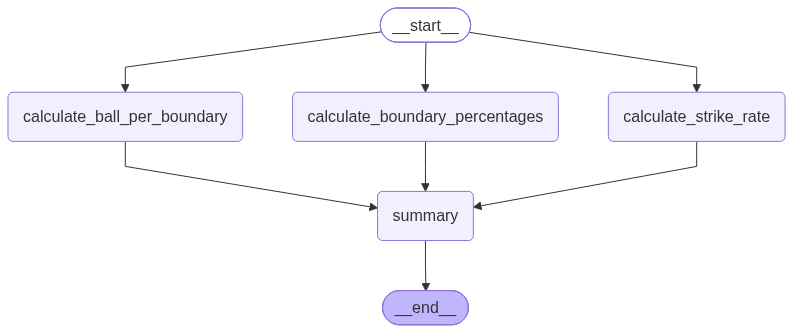

In [44]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

# Workflow for essay evaluation

In [ ]:
"""
          clarity of thoughts      LLM1 (Text feedback and score)
START --> depth of analysis        LLM2 (Text feedback and score) --> Final Evaluation LLM4 (summary feedback + avg score) --> END
          language and expression  LLM3 (Text feedback and score)
"""

In [32]:
from langgraph.graph import START , END , StateGraph
from typing import TypedDict , Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel , Field
import operator


In [25]:
load_dotenv()
model = ChatOpenAI(model_name="gpt-4", temperature=0.7, max_tokens=500)

In [26]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(..., description="Textual feedback from the LLM")
    score: float = Field(..., description="Score given out of 10 by the LLM", ge=0, le=10)

In [27]:
structured_model = model.with_structured_output(EvaluationSchema)

c:\Users\DELL\Desktop\Agentic-AI-Using-LangGraph\myagentvenv\Lib\site-packages\langchain_openai\chat_models\base.py:2489: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [28]:
essay = "my name is moiz"

In [29]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}"

In [30]:
structured_model.invoke(prompt)

EvaluationSchema(feedback='The given text is not an essay. It is merely a personal introduction consisting of one sentence. The sentence itself is grammatically correct, but lacks punctuation. An essay requires much more content, including an introduction, body, and conclusion, as well as a central theme or argument.', score=1.0)

In [46]:
class EvaluationState(TypedDict):
    essay: str
    clarity_of_thoughts: str
    depth_of_analysis: str
    language: str
    final_evaluation: str
    individual_scores: Annotated[list[int], operator.add]
    final_score: float

In [47]:
def cot(state: EvaluationState):
    prompt = f"Evaluate the clarity of thoughts in the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    return {"clarity_of_thoughts": output.feedback, "individual_scores": [output.score]}

def doa(state: EvaluationState):
    prompt = f"Evaluate the depth of analysis in the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    return {"depth_of_analysis": output.feedback, "individual_scores": [output.score]}

def lang(state: EvaluationState):
    prompt = f"Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state['essay']}"
    output = structured_model.invoke(prompt)
    return {"language": output.feedback, "individual_scores": [output.score]}
   
def summary(state: EvaluationState):
    avg_score = sum(state['individual_scores']) / len(state['individual_scores']) if state['individual_scores'] else 0
    prompt = f"Summarize the feedback from the previous evaluations and provide a final evaluation along with an average score out of 10 \n Clarity of Thoughts: {state['clarity_of_thoughts']} \n Depth of Analysis: {state['depth_of_analysis']} \n Language: {state['language']} \n Average Score: {avg_score:.2f}"
    output = structured_model.invoke(prompt)
    return {"final_evaluation": output.feedback, "final_score": avg_score}

In [48]:
graph = StateGraph(EvaluationState)

graph.add_node("clarity_of_thoughts", cot)
graph.add_node("depth_of_analysis", doa)
graph.add_node("language", lang)
graph.add_node("summary", summary)

graph.add_edge(START, "clarity_of_thoughts")
graph.add_edge(START, "depth_of_analysis")
graph.add_edge(START, "language")
graph.add_edge("clarity_of_thoughts", "summary")
graph.add_edge("depth_of_analysis", "summary")
graph.add_edge("language", "summary")
graph.add_edge("summary", END)

workflow = graph.compile()

In [49]:
initial_state = {'essay': essay}

final_state = workflow.invoke(initial_state)

print(final_state)

{'essay': 'my name is moiz', 'clarity_of_thoughts': "The text provided is not an essay. It's just a single sentence stating a person's name. Please provide a more substantial text for evaluation.", 'depth_of_analysis': 'The text provided does not constitute an essay, nor does it provide any depth of analysis. It merely states a name. In order to evaluate the depth of analysis in an essay, please provide a text that explores a specific topic or argument in detail.', 'language': "The text provided does not constitute an essay. An essay is a short piece of writing on a particular subject. It should contain an introduction, body paragraphs, and a conclusion. The text you provided is simply a statement of a person's name. Please provide a more substantial text for evaluation.", 'final_evaluation': "The text provided for evaluation was insufficient as it was only a single sentence stating a person's name. It lacked the necessary elements for an essay such as an introduction, body paragraphs,

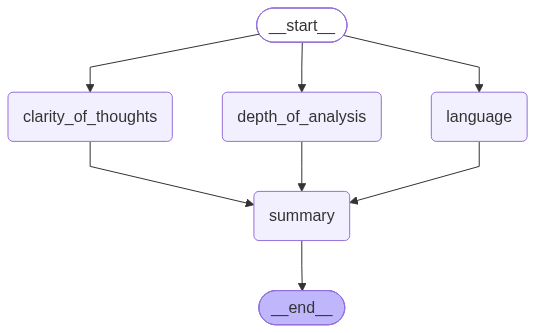

In [44]:
workflow